<a href="https://colab.research.google.com/github/AparajitaY/fastMRi/blob/main/fastMRI_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastmri


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.3 MB/s eta 0:00:00
  Created wheel for runstats: filename=runstats-2.0.0-py3-none-any.whl size=12447 sha256=87fd1594a07dbf5b18be5b3f39e3465e22c66be3ba685db273cfcbdca7266bee
  Stored in directory: /root/.cache/pip/wheels/d1/1d/c6/d1a7f2e1f96534b0da61587bef8e248902945841293bb1186f
Successfully built runstats


In [2]:
import os
import glob
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import torch.optim as optim
import fastmri
from fastmri.data import transforms as T
from fastmri.data.subsample import RandomMaskFunc

from torch.utils.data import Dataset, DataLoader, random_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

project_dir = "/content/drive/MyDrive/fastMRI_project"
checkpoint_dir = os.path.join(project_dir, "checkpoints")
results_dir = os.path.join(project_dir, "results")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

zip_path = "/content/drive/MyDrive/fastMRI/fastmri_subset.zip"

local_zip_path = "/content/fastmri_subset.zip"
local_data_dir = "/content/fastmri_local"

if os.path.exists(local_data_dir):
    shutil.rmtree(local_data_dir)

os.makedirs(local_data_dir, exist_ok=True)

print("Paths made")

Mounted at /content/drive
Paths made


In [4]:
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"ZIP file not found: {zip_path}")

shutil.copy2(zip_path, local_zip_path)

print("ZIP copied to Colab local storage.")

ZIP copied to Colab local storage.


In [5]:
import zipfile

with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
    zip_ref.extractall(local_data_dir)

local_files = sorted(
    glob.glob(
        os.path.join(local_data_dir, "**", "*.h5"),
        recursive=True
    )
)

print("Extracted H5 files:", len(local_files))
print("First file:", local_files[0] if local_files else "None")

Extracted H5 files: 50
First file: /content/fastmri_local/2022091504_T203.h5


In [6]:
def fftshift(x, axes=(-2, -1)):
    return np.fft.fftshift(x, axes=axes)


def ifftshift(x, axes=(-2, -1)):
    return np.fft.ifftshift(x, axes=axes)


def ifft2c(kspace):
    """
    Centered 2D inverse FFT.
    Input shape: (..., H, W)
    """
    image = ifftshift(kspace, axes=(-2, -1))
    image = np.fft.ifft2(image, axes=(-2, -1), norm="ortho")
    image = fftshift(image, axes=(-2, -1))
    return image


def rss_combine(coil_images):
    """
    Root-sum-of-squares coil combination.
    Input shape: (coils, H, W)
    Output shape: (H, W)
    """
    return np.sqrt(np.sum(np.abs(coil_images) ** 2, axis=0))


def create_4x_mask(width, center_fraction=0.08, acceleration=4):
    """
    Creates a Cartesian undersampling mask along the phase-encoding axis.
    """
    num_low_frequency_lines = max(
        1,
        int(round(width * center_fraction))
    )

    num_samples = max(
        num_low_frequency_lines,
        int(round(width / acceleration))
    )

    mask = np.zeros(width, dtype=np.float32)

    center_start = (width - num_low_frequency_lines) // 2
    center_end = center_start + num_low_frequency_lines

    mask[center_start:center_end] = 1.0

    remaining = num_samples - num_low_frequency_lines

    if remaining > 0:
        available_indices = np.concatenate([
            np.arange(0, center_start),
            np.arange(center_end, width)
        ])

        chosen = np.random.choice(
            available_indices,
            size=min(remaining, len(available_indices)),
            replace=False
        )

        mask[chosen] = 1.0

    return mask

In [7]:
class MRISliceDataset(Dataset):
    def __init__(
        self,
        files,
        center_fraction=0.08,
        acceleration=4,
        max_slices_per_file=18
    ):
        self.files = files
        self.center_fraction = center_fraction
        self.acceleration = acceleration
        self.samples = []

        for file_path in self.files:
            with h5py.File(file_path, "r") as hf:
                if "kspace" not in hf:
                    continue

                num_slices = hf["kspace"].shape[0]

                if max_slices_per_file is not None:
                    num_slices = min(
                        num_slices,
                        max_slices_per_file
                    )

                for slice_index in range(num_slices):
                    self.samples.append(
                        (file_path, slice_index)
                    )

        print("Dataset samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file_path, slice_index = self.samples[index]

        with h5py.File(file_path, "r") as hf:
            kspace = hf["kspace"][slice_index]

            if "reconstruction_rss" in hf:
                target = hf["reconstruction_rss"][slice_index]
            else:
                target = None

        kspace = np.asarray(kspace)

        if not np.iscomplexobj(kspace):
            if kspace.shape[-1] == 2:
                kspace = (
                    kspace[..., 0] +
                    1j * kspace[..., 1]
                )
            else:
                kspace = kspace.astype(np.complex64)

        num_coils, height, width = kspace.shape

        mask_1d = create_4x_mask(
            width=width,
            center_fraction=self.center_fraction,
            acceleration=self.acceleration
        )

        mask = mask_1d[None, None, :]
        undersampled_kspace = kspace * mask

        coil_images = ifft2c(undersampled_kspace)
        zero_filled = rss_combine(coil_images)

        if target is None:
            full_coil_images = ifft2c(kspace)
            target = rss_combine(full_coil_images)
        else:
            target = np.asarray(target)

        zero_filled = np.abs(zero_filled).astype(np.float32)
        target = np.abs(target).astype(np.float32)

        scale = np.percentile(target, 99)

        if scale > 0:
            zero_filled = zero_filled / scale
            target = target / scale

        zero_filled = np.clip(zero_filled, 0.0, 1.0)
        target = np.clip(target, 0.0, 1.0)

        zero_filled = torch.from_numpy(
            zero_filled
        ).unsqueeze(0).float()

        target = torch.from_numpy(
            target
        ).unsqueeze(0).float()

        return zero_filled, target

In [8]:
small_files = local_files

dataset = MRISliceDataset(
    small_files,
    center_fraction=0.08,
    acceleration=4,
    max_slices_per_file=18
)

print("Files used:", len(small_files))
print("Total samples:", len(dataset))

Dataset samples: 900
Files used: 50
Total samples: 900


# Training and Validation

In [9]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=split_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 720
Validation samples: 180


# Define UNet

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [11]:
class UNetBetter(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(
            32, out_channels, kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.final(d1))

In [12]:
model = UNetBetter().to(device)

x_test, y_test = next(iter(train_loader))
x_test = x_test.to(device)

with torch.no_grad():
    output_test = model(x_test)

print("Input shape:", x_test.shape)
print("Output shape:", output_test.shape)

Input shape: torch.Size([4, 1, 256, 256])
Output shape: torch.Size([4, 1, 256, 256])


In [13]:
# LOSS AND OPTIMIZER
criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

num_epochs = 10
best_val_loss = float("inf")

In [14]:
# training function
from tqdm.auto import tqdm
import time

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    epoch,
    total_epochs
):
    model.train()

    running_loss = 0.0
    epoch_start = time.time()

    progress_bar = tqdm(
        loader,
        total=len(loader),
        desc=f"Epoch {epoch}/{total_epochs} [TRAIN]",
        unit="batch",
        ncols=120
    )

    for batch_index, (inputs, targets) in enumerate(progress_bar, start=1):
        batch_start = time.time()

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(inputs)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss * inputs.size(0)

        average_loss = running_loss / (
            batch_index * inputs.size(0)
        )

        batch_time = time.time() - batch_start

        progress_bar.set_postfix(
            loss=f"{batch_loss:.5f}",
            avg=f"{average_loss:.5f}",
            time=f"{batch_time:.1f}s"
        )

    epoch_loss = running_loss / len(loader.dataset)
    epoch_time = time.time() - epoch_start

    print(
        f"Training complete | "
        f"Loss: {epoch_loss:.6f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    return epoch_loss

In [15]:
# validate function
def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    epoch,
    total_epochs
):
    model.eval()

    running_loss = 0.0
    validation_start = time.time()

    progress_bar = tqdm(
        loader,
        total=len(loader),
        desc=f"Epoch {epoch}/{total_epochs} [VAL]",
        unit="batch",
        ncols=120
    )

    with torch.no_grad():
        for batch_index, (inputs, targets) in enumerate(
            progress_bar,
            start=1
        ):
            batch_start = time.time()

            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            predictions = model(inputs)
            loss = criterion(predictions, targets)

            batch_loss = loss.item()
            running_loss += batch_loss * inputs.size(0)

            average_loss = running_loss / (
                batch_index * inputs.size(0)
            )

            batch_time = time.time() - batch_start

            progress_bar.set_postfix(
                loss=f"{batch_loss:.5f}",
                avg=f"{average_loss:.5f}",
                time=f"{batch_time:.1f}s"
            )

    validation_loss = running_loss / len(loader.dataset)
    validation_time = time.time() - validation_start

    print(
        f"Validation complete | "
        f"Loss: {validation_loss:.6f} | "
        f"Time: {validation_time / 60:.2f} min"
    )

    return validation_loss

In [16]:
train_losses = []
val_losses = []

num_epochs = 10
best_val_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    print("\n" + "=" * 90)
    print(f"STARTING EPOCH {epoch}/{num_epochs}")
    print("=" * 90)

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        total_epochs=num_epochs
    )

    val_loss = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        epoch=epoch,
        total_epochs=num_epochs
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss
            },
            os.path.join(
                checkpoint_dir,
                "best_unet_4x.pth"
            )
        )

        print(
            f"New best model saved. "
            f"Validation loss: {val_loss:.6f}"
        )
    else:
        print(
            f"No improvement. "
            f"Best validation loss: {best_val_loss:.6f}"
        )

    print(
        f"END OF EPOCH {epoch} | "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f}"
    )


STARTING EPOCH 1/10


Epoch 1/10 [TRAIN]:   0%|                                                                    | 0/180 [00:00<?,…

KeyboardInterrupt: 

# load best checkpoint


In [17]:
best_checkpoint_path = os.path.join(
    checkpoint_dir,
    "best_unet_4x.pth"
)

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best checkpoint loaded.")
print("Saved epoch:", checkpoint["epoch"])
print("Saved validation loss:", checkpoint["val_loss"])

Best checkpoint loaded.
Saved epoch: 9
Saved validation loss: 0.04043509024712774


# Metrics

In [18]:
def evaluate_model(model, loader, device):
    model.eval()

    psnr_values = []
    ssim_values = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            predictions = predictions.cpu().numpy()
            targets = targets.cpu().numpy()

            for prediction, target in zip(predictions, targets):
                prediction = prediction[0]
                target = target[0]

                psnr_value = psnr(
                    target,
                    prediction,
                    data_range=1.0
                )

                ssim_value = ssim(
                    target,
                    prediction,
                    data_range=1.0
                )

                psnr_values.append(psnr_value)
                ssim_values.append(ssim_value)

    return (
        float(np.mean(psnr_values)),
        float(np.mean(ssim_values))
    )

In [19]:
unet_psnr, unet_ssim = evaluate_model(
    model,
    val_loader,
    device
)

print(f"U-Net PSNR: {unet_psnr:.3f} dB")
print(f"U-Net SSIM: {unet_ssim:.4f}")

U-Net PSNR: 24.878 dB
U-Net SSIM: 0.5877


In [20]:
def evaluate_zero_filled(loader):
    psnr_values = []
    ssim_values = []

    for inputs, targets in loader:
        inputs = inputs.numpy()
        targets = targets.numpy()

        for zero_filled, target in zip(inputs, targets):
            zero_filled = zero_filled[0]
            target = target[0]

            psnr_values.append(
                psnr(
                    target,
                    zero_filled,
                    data_range=1.0
                )
            )

            ssim_values.append(
                ssim(
                    target,
                    zero_filled,
                    data_range=1.0
                )
            )

    return (
        float(np.mean(psnr_values)),
        float(np.mean(ssim_values))
    )

In [21]:
zf_psnr, zf_ssim = evaluate_zero_filled(val_loader)

print(f"Zero-filled PSNR: {zf_psnr:.3f} dB")
print(f"Zero-filled SSIM: {zf_ssim:.4f}")

Zero-filled PSNR: 21.153 dB
Zero-filled SSIM: 0.4991


In [22]:
print("\nFINAL BASELINE COMPARISON")
print("-" * 40)
print(f"Zero-filled | PSNR: {zf_psnr:.3f} dB | SSIM: {zf_ssim:.4f}")
print(f"U-Net       | PSNR: {unet_psnr:.3f} dB | SSIM: {unet_ssim:.4f}")
print(f"PSNR gain   : {unet_psnr - zf_psnr:+.3f} dB")
print(f"SSIM gain   : {unet_ssim - zf_ssim:+.4f}")


FINAL BASELINE COMPARISON
----------------------------------------
Zero-filled | PSNR: 21.153 dB | SSIM: 0.4991
U-Net       | PSNR: 24.878 dB | SSIM: 0.5877
PSNR gain   : +3.725 dB
SSIM gain   : +0.0886


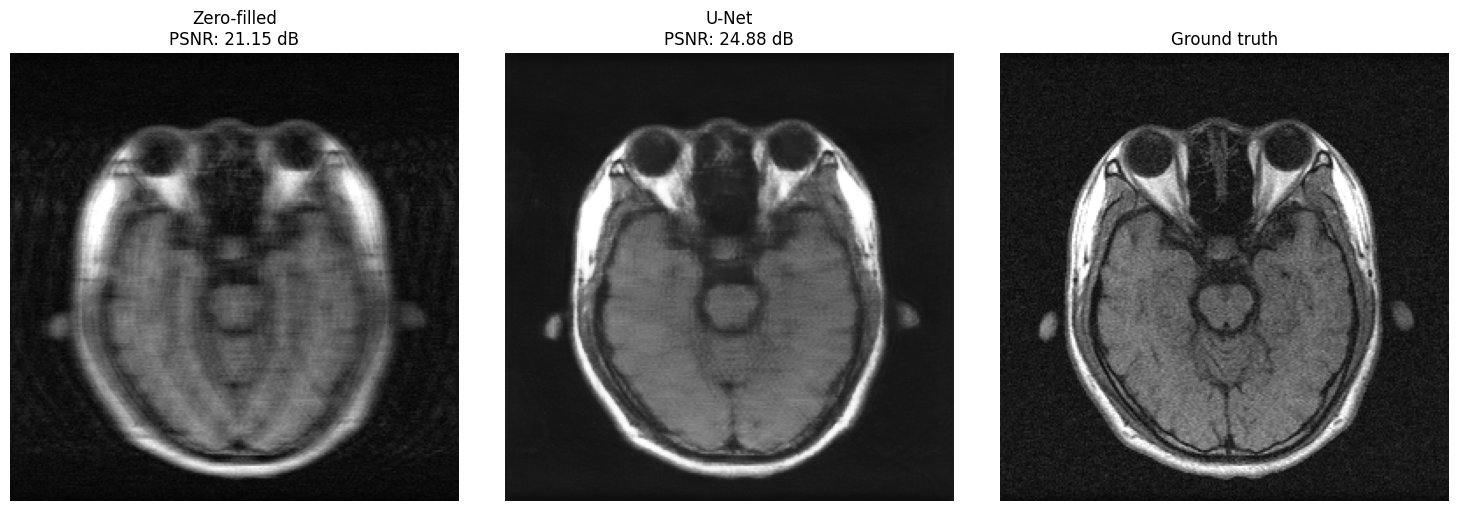

In [23]:
model.eval()

inputs, targets = next(iter(val_loader))
inputs_device = inputs.to(device)

with torch.no_grad():
    predictions = model(inputs_device).cpu()

index = 0

zero_filled_image = inputs[index, 0].numpy()
prediction_image = predictions[index, 0].numpy()
target_image = targets[index, 0].numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(zero_filled_image, cmap="gray", vmin=0, vmax=1)
plt.title(f"Zero-filled\nPSNR: {zf_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prediction_image, cmap="gray", vmin=0, vmax=1)
plt.title(f"U-Net\nPSNR: {unet_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(target_image, cmap="gray", vmin=0, vmax=1)
plt.title("Ground truth")
plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
import json

metrics = {
    "zero_filled_psnr": zf_psnr,
    "zero_filled_ssim": zf_ssim,
    "unet_psnr": unet_psnr,
    "unet_ssim": unet_ssim,
    "psnr_gain": unet_psnr - zf_psnr,
    "ssim_gain": unet_ssim - zf_ssim,
    "best_validation_loss": checkpoint["val_loss"],
    "best_epoch": checkpoint["epoch"]
}

metrics_path = os.path.join(
    results_dir,
    "unet_4x_metrics.json"
)

with open(metrics_path, "w") as file:
    json.dump(metrics, file, indent=4)

print("Metrics saved to:", metrics_path)

Metrics saved to: /content/drive/MyDrive/fastMRI_project/results/unet_4x_metrics.json


# Generative Adversial Network (GAN)

First initialize the generator from the best U-Net checkpoint, then use a PatchGAN discriminator with adversarial plus L1 reconstruction loss. This is standard for reconstruction GANs because L1 preserves image fidelity while adversarial loss encourages sharper local details.



In [28]:
#load unet generator
G = UNetBetter().to(device)

best_checkpoint_path = os.path.join(
    checkpoint_dir,
    "best_unet_4x.pth"
)

unet_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

G.load_state_dict(
    unet_checkpoint["model_state_dict"]
)

print("Generator initialized from the best U-Net checkpoint.")

Generator initialized from the best U-Net checkpoint.


In [29]:
# define discriminator
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2, base_channels=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(
                in_channels,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                base_channels,
                base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                base_channels * 2,
                base_channels * 4,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                base_channels * 4,
                base_channels * 8,
                kernel_size=4,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                base_channels * 8,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, x):
        return self.network(x)

In [30]:
# gan objects
D = PatchDiscriminator().to(device)

adversarial_loss = nn.BCEWithLogitsLoss()
reconstruction_loss = nn.L1Loss()

g_optimizer = optim.Adam(
    G.parameters(),
    lr=1e-5,
    betas=(0.5, 0.999)
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=1e-4,
    betas=(0.5, 0.999)
)

lambda_l1 = 100.0
lambda_adv = 0.01

print("GAN initialized.")
print("L1 weight:", lambda_l1)
print("Adversarial weight:", lambda_adv)

GAN initialized.
L1 weight: 100.0
Adversarial weight: 0.01


In [31]:
# testing gen and disc
test_inputs, test_targets = next(iter(train_loader))

test_inputs = test_inputs.to(device)
test_targets = test_targets.to(device)

with torch.no_grad():
    test_fake = G(test_inputs)

real_pair = torch.cat(
    [test_inputs, test_targets],
    dim=1
)

fake_pair = torch.cat(
    [test_inputs, test_fake],
    dim=1
)

real_output = D(real_pair)
fake_output = D(fake_pair)

print("Generator output shape:", test_fake.shape)
print("Discriminator real output:", real_output.shape)
print("Discriminator fake output:", fake_output.shape)

Generator output shape: torch.Size([4, 1, 256, 256])
Discriminator real output: torch.Size([4, 1, 30, 30])
Discriminator fake output: torch.Size([4, 1, 30, 30])


In [32]:
from tqdm.auto import tqdm
import time

def train_gan_one_epoch(
    G,
    D,
    loader,
    g_optimizer,
    d_optimizer,
    device,
    epoch,
    total_epochs
):
    G.train()
    D.train()

    total_g_loss = 0.0
    total_d_loss = 0.0
    total_l1_loss = 0.0
    total_adv_loss = 0.0

    epoch_start = time.time()

    progress_bar = tqdm(
        loader,
        total=len(loader),
        desc=f"Epoch {epoch}/{total_epochs} [GAN TRAIN]",
        unit="batch",
        ncols=130
    )

    for batch_index, (inputs, targets) in enumerate(
        progress_bar,
        start=1
    ):
        batch_start = time.time()

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # Train discriminator
        with torch.no_grad():
            fake_images = G(inputs).clamp(0, 1)

        real_pair = torch.cat(
            [inputs, targets],
            dim=1
        )

        fake_pair = torch.cat(
            [inputs, fake_images],
            dim=1
        )

        real_prediction = D(real_pair)
        fake_prediction = D(fake_pair)

        real_labels = torch.ones_like(real_prediction)
        fake_labels = torch.zeros_like(fake_prediction)

        d_real_loss = adversarial_loss(
            real_prediction,
            real_labels
        )

        d_fake_loss = adversarial_loss(
            fake_prediction,
            fake_labels
        )

        d_loss = 0.5 * (
            d_real_loss + d_fake_loss
        )

        d_optimizer.zero_grad(set_to_none=True)
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        fake_images = G(inputs).clamp(0, 1)

        fake_pair_for_g = torch.cat(
            [inputs, fake_images],
            dim=1
        )

        fake_prediction_for_g = D(fake_pair_for_g)

        generator_labels = torch.ones_like(
            fake_prediction_for_g
        )

        g_adv_loss = adversarial_loss(
            fake_prediction_for_g,
            generator_labels
        )

        g_l1_loss = reconstruction_loss(
            fake_images,
            targets
        )

        g_loss = (
            lambda_l1 * g_l1_loss +
            lambda_adv * g_adv_loss
        )

        g_optimizer.zero_grad(set_to_none=True)
        g_loss.backward()
        g_optimizer.step()

        total_g_loss += g_loss.item() * inputs.size(0)
        total_d_loss += d_loss.item() * inputs.size(0)
        total_l1_loss += g_l1_loss.item() * inputs.size(0)
        total_adv_loss += g_adv_loss.item() * inputs.size(0)

        average_g_loss = total_g_loss / (
            batch_index * inputs.size(0)
        )

        progress_bar.set_postfix(
            G=f"{g_loss.item():.4f}",
            D=f"{d_loss.item():.4f}",
            L1=f"{g_l1_loss.item():.4f}",
            ADV=f"{g_adv_loss.item():.4f}",
            sec=f"{time.time() - batch_start:.1f}"
        )

    dataset_size = len(loader.dataset)

    return (
        total_g_loss / dataset_size,
        total_d_loss / dataset_size,
        total_l1_loss / dataset_size,
        total_adv_loss / dataset_size,
        (time.time() - epoch_start) / 60
    )

In [36]:
def validate_gan(G, loader, device):
    G.eval()

    psnr_values = []
    ssim_values = []
    l1_values = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = G(inputs).clamp(0, 1)

            l1_values.append(
                torch.mean(
                    torch.abs(predictions - targets)
                ).item()
            )

            predictions = predictions.cpu().numpy()
            targets = targets.cpu().numpy()

            for prediction, target in zip(
                predictions,
                targets
            ):
                prediction = prediction[0]
                target = target[0]

                psnr_values.append(
                    psnr(
                        target,
                        prediction,
                        data_range=1.0
                    )
                )

                ssim_values.append(
                    ssim(
                        target,
                        prediction,
                        data_range=1.0
                    )
                )

    return (
        float(np.mean(l1_values)),
        float(np.mean(psnr_values)),
        float(np.mean(ssim_values))
    )

In [37]:
gan_num_epochs = 5

gan_history = []
best_gan_psnr = -float("inf")

for epoch in range(1, gan_num_epochs + 1):
    print("\n" + "=" * 100)
    print(f"STARTING GAN EPOCH {epoch}/{gan_num_epochs}")
    print("=" * 100)

    (
        g_loss,
        d_loss,
        g_l1_loss,
        g_adv_loss,
        epoch_time
    ) = train_gan_one_epoch(
        G=G,
        D=D,
        loader=train_loader,
        g_optimizer=g_optimizer,
        d_optimizer=d_optimizer,
        device=device,
        epoch=epoch,
        total_epochs=gan_num_epochs
    )

    val_l1, gan_psnr, gan_ssim = validate_gan(
        G,
        val_loader,
        device
    )

    gan_history.append({
        "epoch": epoch,
        "g_loss": g_loss,
        "d_loss": d_loss,
        "g_l1_loss": g_l1_loss,
        "g_adv_loss": g_adv_loss,
        "val_l1": val_l1,
        "psnr": gan_psnr,
        "ssim": gan_ssim
    })

    if gan_psnr > best_gan_psnr:
        best_gan_psnr = gan_psnr

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": G.state_dict(),
                "discriminator_state_dict": D.state_dict(),
                "g_optimizer_state_dict": g_optimizer.state_dict(),
                "d_optimizer_state_dict": d_optimizer.state_dict(),
                "val_l1": val_l1,
                "psnr": gan_psnr,
                "ssim": gan_ssim,
                "lambda_l1": lambda_l1,
                "lambda_adv": lambda_adv
            },
            os.path.join(
                checkpoint_dir,
                "best_gan_4x.pth"
            )
        )

        checkpoint_message = "NEW BEST GAN SAVED"
    else:
        checkpoint_message = "No GAN improvement"

    print(
        f"GAN epoch complete in {epoch_time:.2f} min"
    )
    print(
        f"G loss: {g_loss:.6f} | "
        f"D loss: {d_loss:.6f}"
    )
    print(
        f"L1: {g_l1_loss:.6f} | "
        f"Adversarial: {g_adv_loss:.6f}"
    )
    print(
        f"Validation L1: {val_l1:.6f} | "
        f"PSNR: {gan_psnr:.3f} dB | "
        f"SSIM: {gan_ssim:.4f}"
    )
    print(checkpoint_message)


STARTING GAN EPOCH 1/5


Epoch 1/5 [GAN TRAIN]:   0%|                                                                           | 0/180…

GAN epoch complete in 2.84 min
G loss: 4.254966 | D loss: 0.034333
L1: 0.042157 | Adversarial: 3.921741
Validation L1: 0.039778 | PSNR: 25.045 dB | SSIM: 0.5886
NEW BEST GAN SAVED

STARTING GAN EPOCH 2/5


Epoch 2/5 [GAN TRAIN]:   0%|                                                                           | 0/180…

GAN epoch complete in 2.86 min
G loss: 4.243984 | D loss: 0.110490
L1: 0.042013 | Adversarial: 4.272904
Validation L1: 0.039592 | PSNR: 25.105 dB | SSIM: 0.5899
NEW BEST GAN SAVED

STARTING GAN EPOCH 3/5


...

GAN epoch complete in 2.84 min
G loss: 4.225767 | D loss: 0.029635
L1: 0.041784 | Adversarial: 4.737390
Validation L1: 0.039625 | PSNR: 25.072 dB | SSIM: 0.5912
No GAN improvement

STARTING GAN EPOCH 4/5


Epoch 4/5 [GAN TRAIN]:   0%|                                                                           | 0/180…

GAN epoch complete in 2.91 min
G loss: 4.239502 | D loss: 0.005608
L1: 0.041830 | Adversarial: 5.646203
Validation L1: 0.039749 | PSNR: 25.105 dB | SSIM: 0.5903
NEW BEST GAN SAVED

STARTING GAN EPOCH 5/5


Epoch 5/5 [GAN TRAIN]:   0%|                                                                           | 0/180…

GAN epoch complete in 2.89 min
G loss: 4.185165 | D loss: 0.233296
L1: 0.041540 | Adversarial: 3.119475
Validation L1: 0.039841 | PSNR: 25.090 dB | SSIM: 0.5907
No GAN improvement


In [38]:
best_gan_path = os.path.join(
    checkpoint_dir,
    "best_gan_4x.pth"
)

best_gan_checkpoint = torch.load(
    best_gan_path,
    map_location=device
)

G.load_state_dict(
    best_gan_checkpoint["model_state_dict"]
)

G.eval()

gan_psnr = best_gan_checkpoint["psnr"]
gan_ssim = best_gan_checkpoint["ssim"]

print("\nFINAL MODEL COMPARISON")
print("-" * 50)
print(
    f"Zero-filled | PSNR: {zf_psnr:.3f} dB | "
    f"SSIM: {zf_ssim:.4f}"
)
print(
    f"U-Net       | PSNR: {unet_psnr:.3f} dB | "
    f"SSIM: {unet_ssim:.4f}"
)
print(
    f"GAN         | PSNR: {gan_psnr:.3f} dB | "
    f"SSIM: {gan_ssim:.4f}"
)
print("-" * 50)
print(
    f"GAN vs U-Net PSNR change: "
    f"{gan_psnr - unet_psnr:+.3f} dB"
)
print(
    f"GAN vs U-Net SSIM change: "
    f"{gan_ssim - unet_ssim:+.4f}"
)


FINAL MODEL COMPARISON
--------------------------------------------------
Zero-filled | PSNR: 21.153 dB | SSIM: 0.4991
U-Net       | PSNR: 24.878 dB | SSIM: 0.5877
GAN         | PSNR: 25.105 dB | SSIM: 0.5903
--------------------------------------------------
GAN vs U-Net PSNR change: +0.228 dB
GAN vs U-Net SSIM change: +0.0026


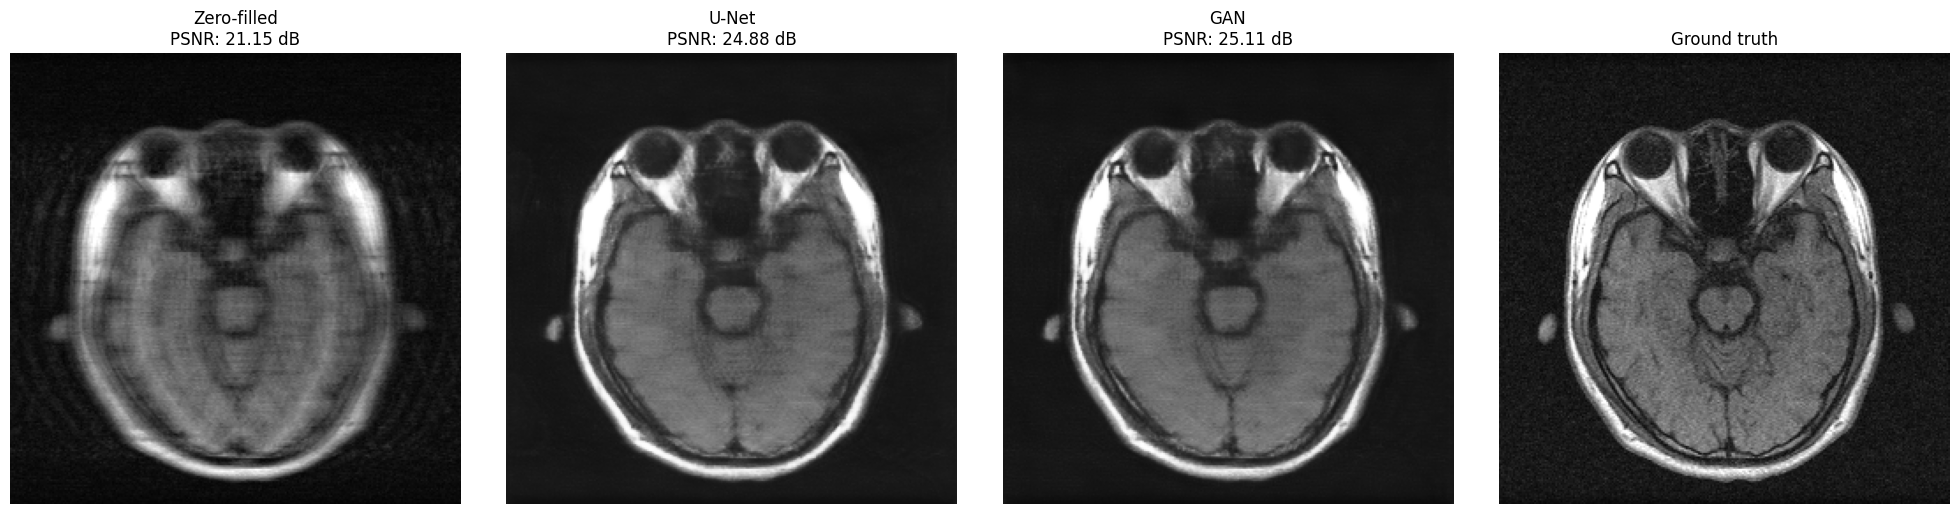

In [39]:
G.eval()

inputs, targets = next(iter(val_loader))
inputs_device = inputs.to(device)

with torch.no_grad():
    gan_predictions = G(inputs_device).cpu()

index = 0

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(inputs[index, 0], cmap="gray", vmin=0, vmax=1)
plt.title(f"Zero-filled\nPSNR: {zf_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    predictions[index, 0],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title(f"U-Net\nPSNR: {unet_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    gan_predictions[index, 0],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title(f"GAN\nPSNR: {gan_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(targets[index, 0], cmap="gray", vmin=0, vmax=1)
plt.title("Ground truth")
plt.axis("off")

plt.tight_layout()
plt.show()